# Импорт необходимых библиотек


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors as mcolors
import seaborn as sns
import scipy.stats as st
from statsmodels.stats.proportion import proportions_ztest

# Загрузка данных

In [2]:
reg_data = pd.read_csv('../shared/problem1-reg_data.csv', sep=';')
auth_data = pd.read_csv('../shared/problem1-auth_data.csv', sep=';')
ab_data = pd.read_csv('../shared/problem2.csv', sep=';')

# Выполнение заданий
## Задание 1

Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока). 
Функция должна быть написана на python. В ходе решения можно тестировать работу функции как на полном датасете, так и на части (сэмпле) данных.

Для начала посчитаем retention без функции, в конце объеденим в функцию.

Смотрим структуру данных:

In [3]:
reg_data.head(3)

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3


In [4]:
auth_data.head(3)

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2


In [5]:
reg_data.shape

(1000000, 2)

In [6]:
auth_data.shape

(9601013, 2)

In [7]:
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB


In [8]:
auth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB


In [9]:
# проверяем есть ли в данных по аутентификации пользователи без регистрации
auth_data['uid'].nunique() - reg_data['uid'].nunique()

0

Данные не содержат пропусков, в данных по аутентификации нет пользователей без регистрации.
Данные о врмени представлены в формате Unix timestamp. Необходимо преобразовать в datetime.

Параметры функции cohort_retention:

reg_data - датаферйм с данными по регистрации;

auth_data - датафрейм с данными по аутентификации;

start_date - начальная дата регистрации (для семпла данных);

end_date - последняя дата регистрации (для семпла данных);

max_date ограничение количества дней с момента регистрации.

In [10]:
def cohort_retention(reg_data, auth_data, start_date=None, end_date=None, max_days=30):
    
    # создаем копии данных
    reg = reg_data[['uid', 'reg_ts']].copy()
    auth = auth_data[['uid', 'auth_ts']].copy()
    
    # переводим формат времени регистрации и аутентификации в datetime
    reg['reg_date'] = pd.to_datetime(reg['reg_ts'], unit='s').dt.floor('D')
    auth['auth_date'] = pd.to_datetime(auth['auth_ts'], unit='s').dt.floor('D')
    
    # фильтр по датам
    if start_date:
        reg = reg[reg['reg_date'] >= pd.to_datetime(start_date)]
    if end_date:
        reg = reg[reg['reg_date'] <= pd.to_datetime(end_date)]
    
    # оставляем только нужных пользователей
    auth = auth[auth['uid'].isin(reg['uid'])]
    
    # объединяем данные регистрации и аутентификации
    df = auth.merge(reg[['uid', 'reg_date']], on='uid')
    
    # считаем дни с момента регистрации
    df['days_from_reg'] = (df['auth_date'] - df['reg_date']).dt.days
    df = df[(df['days_from_reg'] >= 0) & (df['days_from_reg'] <= max_days)]
    
    # на всякий случай удаляем дубликаты
    df = df.drop_duplicates(['uid', 'reg_date', 'days_from_reg'])
    
    # определяем размер когорты
    cohort_size = reg.groupby('reg_date')['uid'].nunique()
    
    # считаем retention
    retention = (
        df.groupby(['reg_date', 'days_from_reg'])['uid']
        .nunique()
        .unstack()
    )
    
    retention = retention.divide(cohort_size, axis=0)
    
    return retention

In [11]:
# тестируем функцию на данныех за последние 30 дней
retention = cohort_retention(
    reg_data,
    auth_data,
    start_date='2020-08-23',
    end_date='2020-09-23',
    max_days=30
)

In [12]:
retention.head()

days_from_reg,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
reg_date,,,,,,,,,,,,,,,,,,,,,
2020-08-23,1.0,0.024968,0.038412,0.048656,0.049296,0.069782,0.081946,0.056978,0.051216,0.045455,...,0.039693,0.044174,0.033931,0.039052,0.031370,0.036492,0.041613,0.028809,0.030730,0.033931
2020-08-24,1.0,0.017891,0.041534,0.042812,0.051118,0.057508,0.076038,0.060064,0.049201,0.051757,...,0.035144,0.036422,0.034505,0.044728,0.031310,0.032588,0.031310,0.031310,0.028115,0.012780
2020-08-25,1.0,0.019783,0.044033,0.047862,0.056796,0.052967,0.052967,0.062540,0.037013,0.057435,...,0.035099,0.035737,0.032546,0.032546,0.044033,0.028079,0.031270,0.031908,0.022974,NaN
2020-08-26,1.0,0.014650,0.034395,0.042038,0.045223,0.064331,0.065605,0.059873,0.045860,0.043312,...,0.026115,0.042675,0.032484,0.027389,0.029299,0.028025,0.027389,0.016561,NaN,NaN
2020-08-27,1.0,0.016529,0.033694,0.047680,0.052130,0.055308,0.061666,0.057216,0.043229,0.054037,...,0.046408,0.029879,0.029879,0.038779,0.033694,0.027336,0.014622,NaN,NaN,NaN


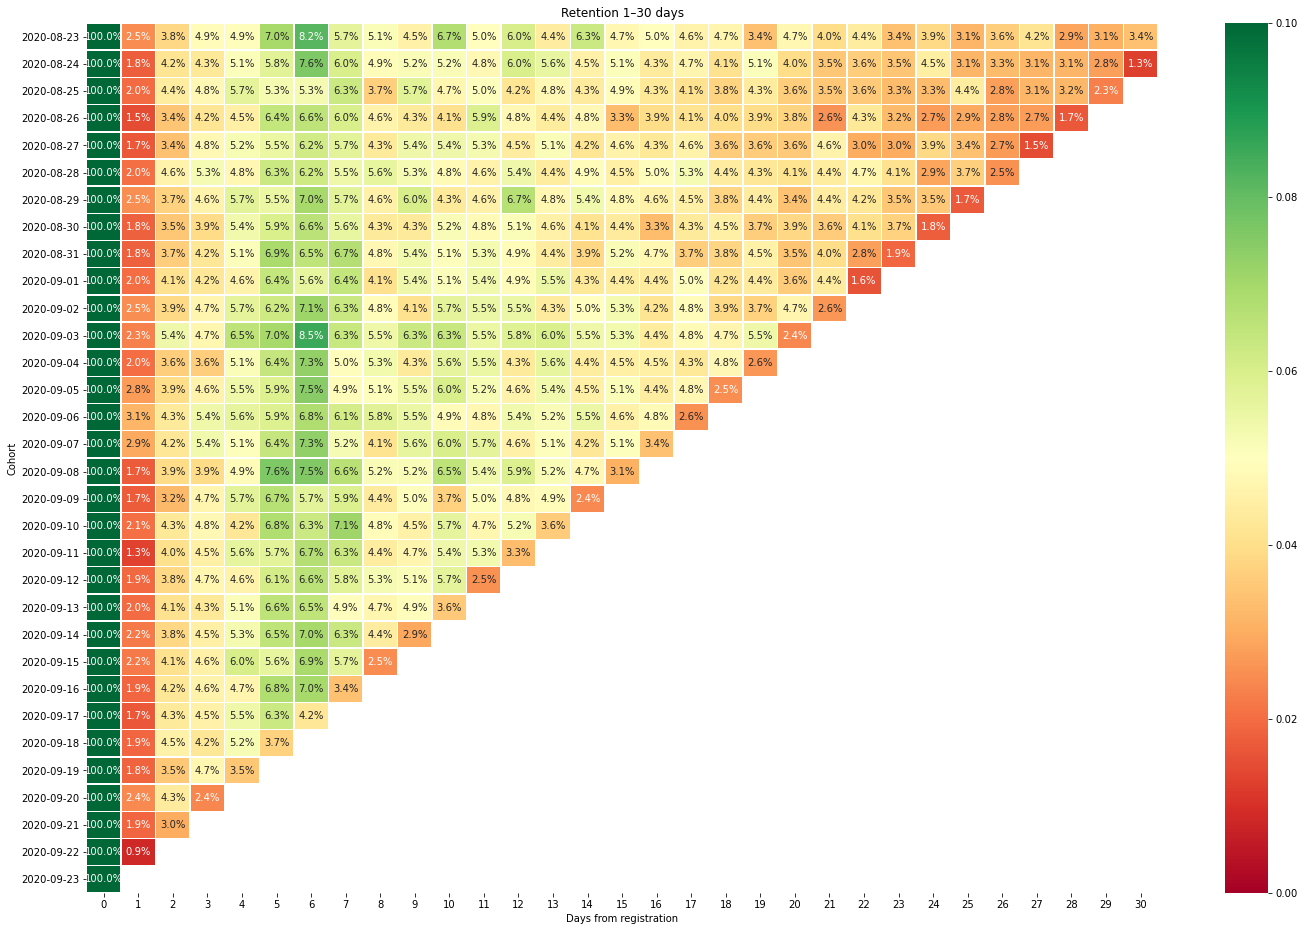

In [13]:
# визуализируем retention по семплу данных
retention.index = pd.to_datetime(retention.index).strftime('%Y-%m-%d')
plt.figure(figsize=(24, 16))

sns.heatmap(
    retention,
    cmap='RdYlGn',
    vmin=0,
    vmax=0.1,
    annot=True,
    fmt='.1%',
    linewidths=0.5)
plt.title('Retention 1–30 days')
plt.xlabel('Days from registration')
plt.ylabel('Cohort')
plt.show()

Судя по сэмплу данных, максимальный retention достигается на 5-7 день с момента регистрации. 

In [14]:
# тестируем функцию на полных данных
retention = cohort_retention(
    reg_data,
    auth_data,
    max_days=30
)

In [15]:
retention.head()

days_from_reg,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
reg_date,,,,,,,,,,,,,,,,,,,,,
1998-11-18,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-07-22,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN
2000-01-13,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-28,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-09-16,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Задание 2

Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

Ранее загружен файл problem2.csv из папки shared с указанными в задании данными. Посмортрим на данные.

In [16]:
ab_data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [17]:
ab_data.describe()

,user_id,revenue
count,404770.000000,404770.000000
mean,202385.500000,26.083435
std,116847.178567,681.652928
min,1.000000,0.000000
25%,101193.250000,0.000000
50%,202385.500000,0.000000
75%,303577.750000,0.000000
max,404770.000000,37433.000000


In [18]:
# посчитаем среднее, медиану, стандартное отклонение по выручке 
ab_data.groupby('testgroup')['revenue'].agg(mean_revenue='mean', median_revenue='median', std_revenue='std')

,mean_revenue,median_revenue,std_revenue
testgroup,,,
a,25.413720,0.0,920.768137
b,26.751287,0.0,287.324162


Средние значения различаются не сильно, медиана равна нулю из-за того что платящие пользователи < 1%. стандартное отклонение сильно различается по группам. Можно сделать предварительный вывод о различии в группах пользователей. 

In [19]:
# сделаем таблицу с основными показателями по тестовой и контрольной группе. 
group_data = ab_data.groupby('testgroup').agg(
    total_revenue=('revenue', 'sum'),
    total_users=('user_id', 'count'),
    paying_users = ('revenue', lambda x: (x > 0).sum()))
group_data

,total_revenue,total_users,paying_users
testgroup,,,
a,5136189,202103,1928
b,5421603,202667,1805


In [20]:
# добавим колонки с основными метриками по группам
group_data['conversion'] = group_data['paying_users'] / group_data['total_users'] * 100
group_data['ARPU'] = group_data['total_revenue'] / group_data['total_users']
group_data['ARPPU'] = group_data['total_revenue'] / group_data['paying_users']
group_data

,total_revenue,total_users,paying_users,conversion,ARPU,ARPPU
testgroup,,,,,,
a,5136189,202103,1928,0.953969,25.413720,2663.998444
b,5421603,202667,1805,0.890624,26.751287,3003.658172


Из результатов мы видим что в тестовой группе: конверсия в платящего упала примерно на 6%, ARPU(Average revenue per user) выросла примерно на 5%, а ARPPU (Average revenue per paying user) выросла примерно на 12%. Мы видим, что при снижении конверсии в платящего выручка на одного платящего сильно выросла на 12%. Чтобы сделать однозначный вывод, необходимо дополнительно проверить данные. 

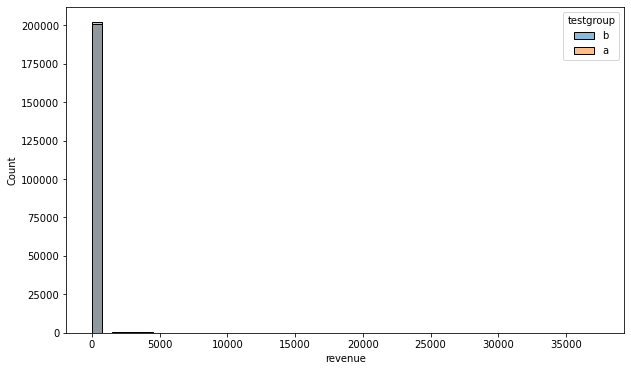

In [21]:
# построим распределение выручка
plt.figure(figsize=(10, 6))
sns.histplot(data=ab_data, x='revenue', hue='testgroup', bins=50)

График нечитаемый. Возьмем только платящих пользователей. 

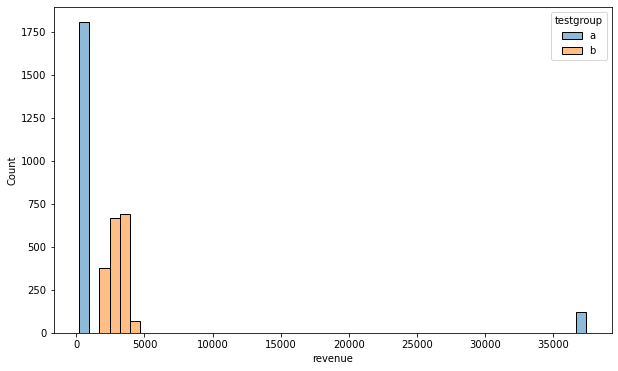

In [22]:
# Берем платящих пользователей по категориям (менее 1% от всех пользователей).
plt.figure(figsize=(10, 6))
sns.histplot(data=ab_data[ab_data['revenue'] > 0], x='revenue', hue='testgroup', bins=50)
plt.show()

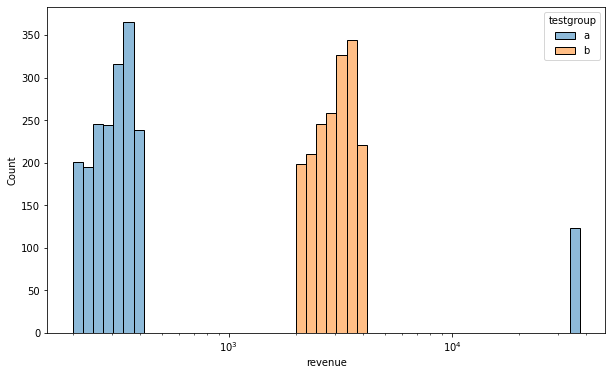

In [23]:
# построим логарифмический график, потому что данные распределены очень неравномерно.
plt.figure(figsize=(10, 6))
sns.histplot(data=ab_data[ab_data['revenue'] > 0], x='revenue', hue='testgroup', bins=50, log_scale=True)
plt.show()

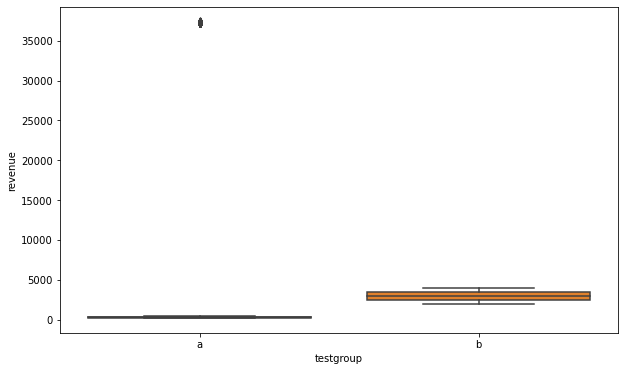

In [24]:
# построим боксплот для оценки распределения 
plt.figure(figsize=(10, 6))
sns.boxplot(data=ab_data[ab_data['revenue'] > 0], x='testgroup', y='revenue')
plt.show()

Из графиков мы видим, что в контрольной группе присутствуют экстремальные выбросы, тогда как основная масса пользователей платит значительно меньше.
В тестовой группе распределение более компактное и смещено в сторону более высоких значений, что говорит о системном увеличении среднего чека.
Таким образом, рост ARPU в тестовой группе обусловлен не отдельными крупными платежами, а изменением поведения пользователей в целом.


In [25]:
# посчитаем квантили по платящим пользователям
ab_data[ab_data['revenue'] > 0].groupby('testgroup')['revenue'].quantile([0.5, 0.9, 0.99])

testgroup      
a          0.50      311.00
           0.90      393.30
           0.99    37340.73
b          0.50     3022.00
           0.90     3795.80
           0.99     3981.92
Name: revenue, dtype: float64

Медианная выручка по платящим пользователям в тестовой группе выше в 10 раз чем в контрольной. 

### Проверка статистической значимости ARPU

Для проверки статистической значимости различий по ARPU используем bootstrap.
Это связано с тем, что распределение выручки содержит большое количество нулевых значений, имеет сильную асимметрию и выбросы, поэтому предпосылки параметрических тестов (например, t-test) не выполняются.
Bootstrap позволяет оценить распределение разницы средних между группами без предположения о нормальности данных.

In [31]:
# функция для bootstrap-сравнения двух выборок
def two_sample_boot(x, y, stat, reps=500):
   
    boot_data = []

    for _ in range(reps):
        # берём bootstrap-выборки (с возвращением)
        sample_x = x.sample(frac=1, replace=True)
        sample_y = y.sample(frac=1, replace=True)
        
        # считаем разницу статистик
        sample_stat_diff = stat(sample_x) - stat(sample_y)
        
        # сохраняем результат
        boot_data.append(sample_stat_diff)

    return np.array(boot_data)

In [32]:
# выделяем группы
control = ab_data[ab_data['testgroup'] == 'a']['revenue']
test = ab_data[ab_data['testgroup'] == 'b']['revenue']

# считаем bootstrap-разницу средних
boot_diff_arpu = two_sample_boot(test, control, np.mean, reps=500)

# считаем 95% доверительный интервал
ci = np.quantile(boot_diff_arpu, [0.025, 0.975])

print(ci)

[-2.9612782   5.34223613]


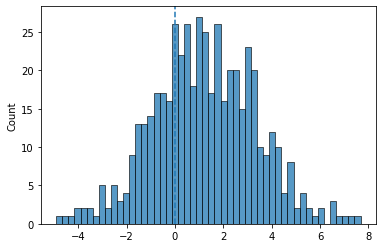

In [33]:
sns.histplot(boot_diff_arpu, bins=50)
plt.axvline(0, linestyle='--')
plt.show()

Доверительный интервал разницы ARPU включает 0, что не позволяет сделать вывод о статистически значимом различии между группами. Несмотря на наблюдаемый рост ARPU в тестовой группе, этот эффект может быть обусловлен случайными колебаниями.

### Проверка статистической значимости ARPPU

Для проверки статистической значимости различий по ARPPU также можем использовать bootstrap. 
ARPPU (Average revenue per paying user) - средний доход на одного платящего пользователя. Для этого отфильтруем датаферйм по revenue > 0.

In [36]:
# выделяем группы
control_arppu = ab_data[(ab_data['testgroup'] == 'a') & (ab_data['revenue'] > 0)]['revenue']
test_arppu = ab_data[(ab_data['testgroup'] == 'b') & (ab_data['revenue'] > 0)]['revenue']

# считаем bootstrap-разницу средних
boot_diff_arppu = two_sample_boot(test_arppu, control_arppu, np.mean, reps=500)

# считаем 95% доверительный интервал
ci_arppu = np.quantile(boot_diff_arppu, [0.025, 0.975])

print(ci_arppu)

[-55.03895201 716.57411046]


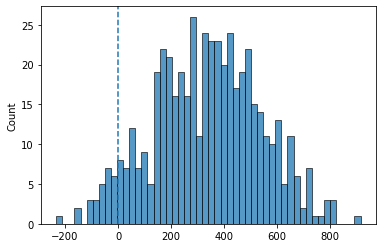

In [37]:
sns.histplot(boot_diff_arppu, bins=50)
plt.axvline(0, linestyle='--')
plt.show()

Доверительный интервал разницы ARPPU включает 0, что не позволяет сделать вывод о статистически значимом различии между группами. Несмотря на наблюдаемый рост ARPPU в тестовой группе, этот эффект может быть обусловлен случайными колебаниями.

### Проверка статистической значимости CR

Конверсия в платящего бинарная метрика (платил/не платил).
Для анализа конверсии в платящего пользователя будем использовать z-тест.

In [38]:
group_data

,total_revenue,total_users,paying_users,conversion,ARPU,ARPPU
testgroup,,,,,,
a,5136189,202103,1928,0.953969,25.413720,2663.998444
b,5421603,202667,1805,0.890624,26.751287,3003.658172


In [39]:
# данные
paying_users = [1928, 1805] #группы a, b
total_users = [202103, 202667] #группы a, b

stat, p_value = proportions_ztest(paying_users, total_users)

print(f"z-stat: {stat}")
print(f"p-value: {p_value}")

z-stat: 2.108028495889841
p-value: 0.035028524642854865


p-value < 0,05 означает, что различные данные акционных предложений оказывают статистическо значимое влияние на CR (долю плтатящих пользователей)

### Вывод
1. Анализ метрик по группам. Из результатов мы видим что в тестовой группе: конверсия в платящего упала примерно на 6%, ARPU(Average revenue per user) выросла примерно на 5%, а ARPPU (Average revenue per paying user) выросла примерно на 12%. Мы видим, что при снижении конверсии в платящего выручка на одного платящего сильно выросла на 12%.
2. Результат оценки статистической значимости метрик A/B-теста: 
- рост ARPU и ARPPU в тестовой группе не показали статистически значимых различий между группами.
- конверсия в платящего пользователя в тестовой группе статистически значимо снизилась. 
3. По результатам A/B-теста и исходя из статистической значимости изменения метрик, можно сделать вывод что ARPU и ARPPU статистически значимо не изменились, а конверсия в платящего снизилась. Таким образом можно сделать вывод, что тестовые акционные предложения как минимум не лучше, чем в контрольной группе и их внедрение на всех пользователей экономически нецелесообразно. 
4. Данные по выручке показывают, что контрольная и тестовая группа не пересекаются по значениям выручки на пользователя, что требует детальной проверки формирования, выборки и гипотизы для A/B текста.  


## Задание 3

В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

С помощью каких метрик можно оценить результаты последнего прошедшего события?

Для ответа распределю метрики по этапам взаимодействия клиента с продуктом с помощью фреймворка AARRR, немного адаптировав его под игровой кейс: 
1. Привлечение. Оцениваем привлекает ли событие игроков. Метрики показывают насколько событие заметно и интересно для участия. 
    Метрики: - доля пользователей/активных пользователей зашедших в событие;
             - количество новых пользователей привлеченных событием;
             - клики / переходы в событие.
2. Активация. Начал ли пользователь взаимодействовать с событием. Метрики показывают есть ли входной барьер для участия.
    Метрики: - доля пользователей перешедших в событие и начаавших прохождение;
             - время до первого уровня;
             - время прохождения первых уровней.
3. Удержание. Позволяет оценить возвращаются ли пользователи в событие. Метрики показывают удерживает ли событие интерес. 
    Метрики: - retention участников события
             - среднее число дней участия
             - частота сессий в событии
             - среднее время участия
             - DAU / WAU во время ивента
4. Прогресс. Оценвиваем прохождение события. Метрики позволяют оценить сложность. 
    Метрики: - среднее число пройденных уровней
             - воронка прохождения уровней
             - доля завершивших событие
             - число попыток на уровень
5. Монетизация. Оцениваем бизнес-эффект события. 
    Метрики: - ARPU / ARPPU участников
             - конверсия в платящих
             - выручка во время события
             - покупки, связанные с событием
6. Ценность наград. Оцениваем значимость события в контексте игры.
    Метрики: ARPU / ARPPU участников
             - доля игроков, получивших награды
             - использование наград после события
Перечисленные метрики оценивающие тематическое событие необходимо сравнивать с теми же метриками в период игры без событий. Также с помощью этих метрик можно сравнивать события между собой. 

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

Введение наказаний за неудачное прохождения принипиально меняет концепцию мотивации игрока: раньше была  только позитивная мотивация (пряник), теперь есть и негативная мотивация (кнут). Таким образом, меняется не только уровень сложности, но и сам принцип взаимодействия игрока с событием: вместо движения только вперёд игрок может попадать в цикл потерь прогресса. Результатом такого нововедения может являться как повышение вовлеченности и интереса, так и рост фрустрации игроков. 

Базовые метрики остаются неизменными, но требуется добавление и расширение метрик нацеленных на сложность события/уровней, поведения игроков внутри события, изменение вороники прохождения, влияния на монетизацию.
Ключевые дополнительные метрики для данного кейса: среднее число откатов, глубина отката, доля игроков столкнувшихся с откатом, вероятность выхода после неудачи, число неудачных попыток подряд, уровни с максиальными отктами, рост покупок бустеров облегчающих прохождение, влияние на retention, изменение конверсии в платящих. 

При стандартной механике событие оценивается через вовлечение, прохождение, удержание и монетизацию.
При добавлении откатов назад набор метрик расширяется и смещается в сторону анализа пользовательского опыта, так как важно учитывать не только результат, но и цену, которой он достигается. Кроме того, при введении "негативной мотивации" необходимо дополнительно тестировать контент события, чтобы избежать провальных событий с резким оттоком клиентов. Исходя из пользовательского опыта системы наказания и отката при неудачах практически не встречается в играх. Пристутсвует система "мягких откатов", например потеря жизней. 